# 🏠 House Price Prediction using Machine Learning

### Project Objective

The goal of this project is to build a Machine Learning model that predicts house prices based on various property features such as area, location, quality, garage, bedrooms, bathrooms, and many other attributes.

This project covers the complete Machine Learning workflow including:

- Data Loading
- Data Understanding
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Price Prediction

# 📚 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 📂 Load Dataset

In [2]:
df = pd.read_csv('data/train.csv')

# 👀 Preview Dataset

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 📏 Dataset Shape

In [4]:
df.shape

(1460, 81)

### Observation

- The dataset contains 1460 rows and 81 columns.
- The target variable is **SalePrice**.
- The dataset contains both numerical and categorical features.

# 📊 Dataset Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Observation

- The dataset contains **1460 rows** and **81 columns**.
- It has **35 integer columns**, **3 float columns**, and **43 categorical columns**.
- The target variable is **SalePrice**.

### Observation

- Several columns contain missing values.
- Columns such as **LotFrontage**, **MasVnrType**, **FireplaceQu**, **PoolQC**, **Fence**, and **MiscFeature** have missing data.
- These missing values will be handled during the data cleaning phase.

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Observation

- The average house price (Mean = 180,921) is higher than the median house price (Median = 163,000).
- This indicates that the dataset may contain some high-priced houses (outliers) that increase the average price.
- We will verify this later using data visualization.

In [7]:
df.describe(include=object)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [8]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# 📊 Exploratory Data Analysis (EDA)

## Distribution of Target Variable (SalePrice)

Before building a Machine Learning model, it is important to understand the distribution of the target variable and identify potential outliers.

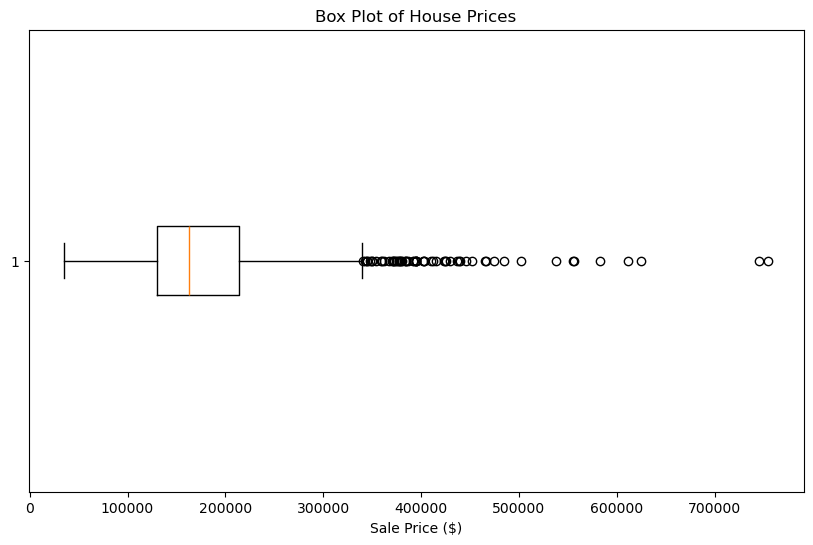

In [9]:
plt.figure(figsize=(10,6))

plt.boxplot(df["SalePrice"], vert=False)

plt.title("Box Plot of House Prices")

plt.xlabel("Sale Price ($)")

plt.show()

# Missing Values Analysis

Before building a machine learning model, it is important to identify missing values.

Missing data can reduce model performance and may require handling through techniques such as imputation or removing columns with excessive missing values.

In this step, we calculate the number and percentage of missing values for each feature.

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)


missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.head(20)

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


# Removing Columns with Excessive Missing Values

Some features contain more than 80–90% missing values.

Keeping these columns provides very little information and may negatively affect the machine learning model.

Therefore, these features are removed before further preprocessing.

In [11]:
drop_columns = missing_df[missing_df['Percentage']>80].index
drop_columns
df = df.drop(columns=drop_columns)#Removing Values 


In [12]:
df.shape

(1460, 77)

# Target Variable Analysis (SalePrice)

Before building a machine learning model, it is important to understand the target variable.

We analyze the distribution of house prices to identify:

- Overall price distribution
- Skewness
- Potential outliers
- Whether data transformation may be required

This helps in selecting appropriate preprocessing techniques and machine learning algorithms.

In [13]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

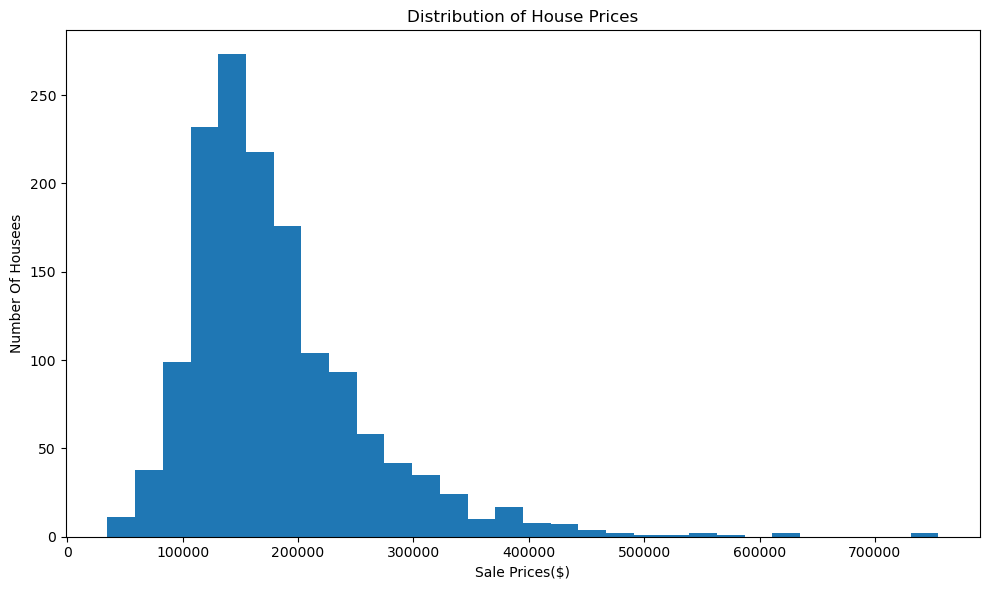

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Prices($)")
plt.ylabel("Number Of Housees")

plt.tight_layout()
plt.show()

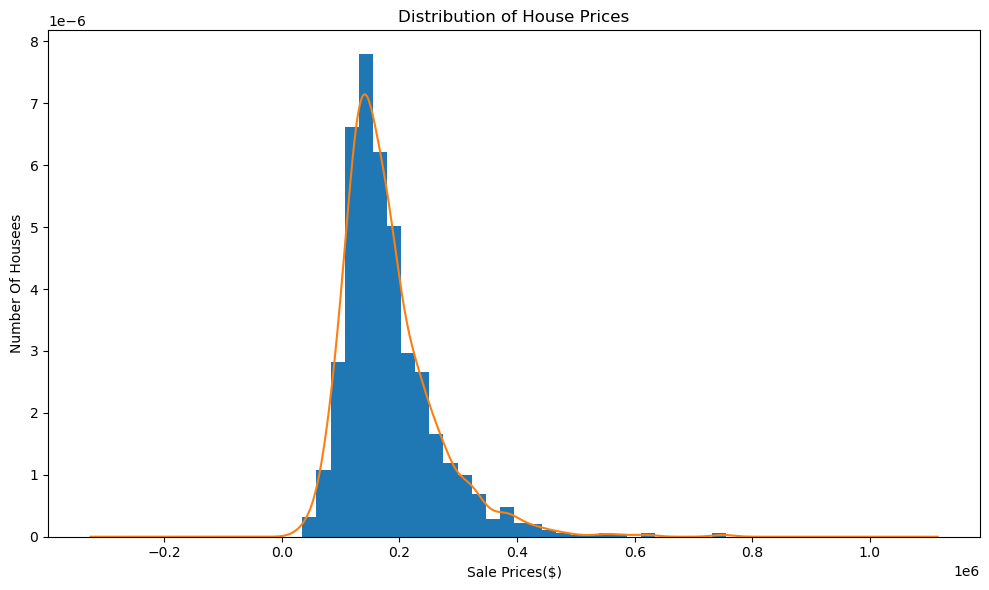

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ax = df['SalePrice'].plot(
    kind='hist',
    bins=30,
    density=True)
ax1 = df['SalePrice'].plot(
    kind='kde')

plt.title("Distribution of House Prices")
plt.xlabel("Sale Prices($)")
plt.ylabel("Number Of Housees")

plt.tight_layout()
plt.show()

### Insights

- Average house price is around $180,921.
- Median price is $163,000.
- The maximum price is $755,000.
- The large gap between the maximum and the 75th percentile indicates the presence of outliers.

## Correlation Analysis

We will identify which numerical features have the strongest relationship with the target variable (SalePrice). This helps us understand which features are most useful for predicting house prices.

In [16]:
# Correlation of numerical features with SalePrice

correlation = df.corr(numeric_only=True)

saleprice_corr = correlation["SalePrice"].sort_values(ascending=False)

saleprice_corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

### Insight

The strongest positive correlations with SalePrice are OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF.

This indicates that larger houses, better construction quality, and bigger garages generally lead to higher selling prices.

These features are expected to play an important role in building an accurate prediction model.

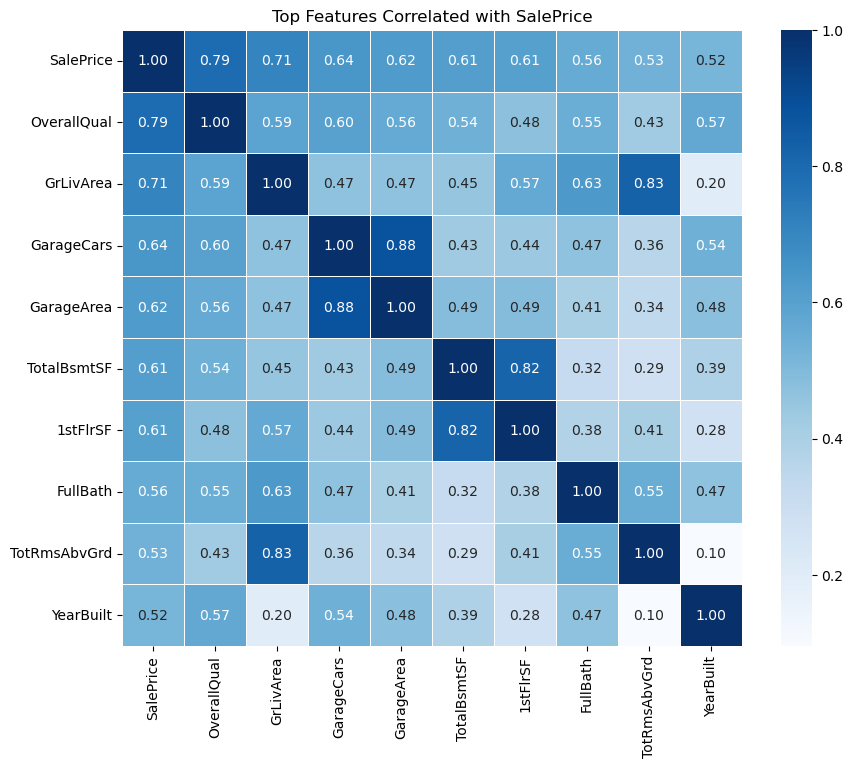

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix
correlation = df.corr(numeric_only=True)

# Top 10 features most correlated with SalePrice
top_features = (
    correlation["SalePrice"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Correlation among top features
top_corr = df[top_features].corr()

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    top_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Top Features Correlated with SalePrice")
plt.show()

### Insight

The heatmap confirms that OverallQual and GrLivArea have the strongest positive relationship with SalePrice.

GarageCars and GarageArea are also highly correlated with each other, indicating that houses with larger garages usually accommodate more vehicles.

Similarly, TotalBsmtSF and 1stFlrSF show a strong relationship because larger basements often support larger ground-floor areas.

These observations help identify the most influential features for predicting house prices while also highlighting variables that contain similar information.


# Feature Relationships with Sale Price

To understand which house features have the strongest impact on sale prices, we visualize the relationship between important numerical features and the target variable (SalePrice).

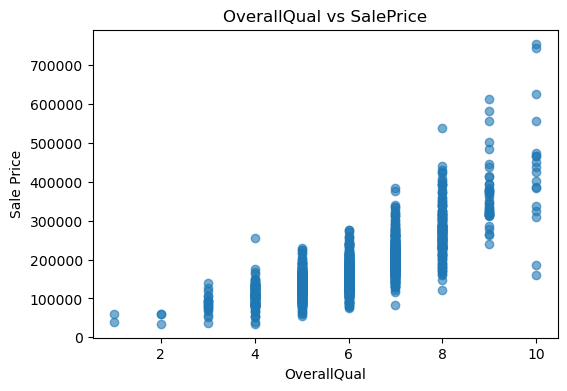

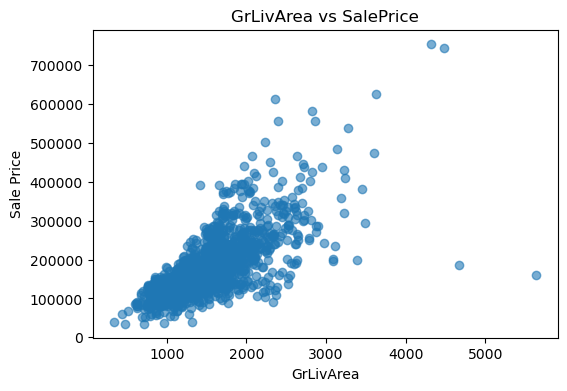

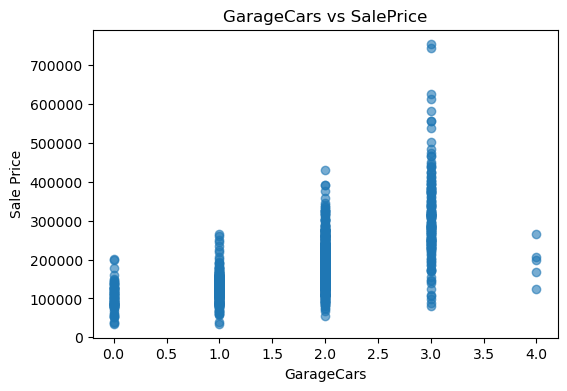

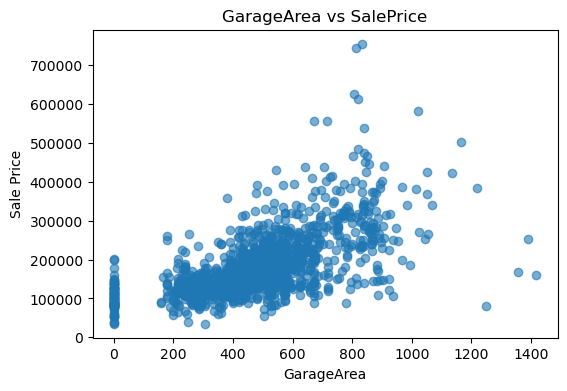

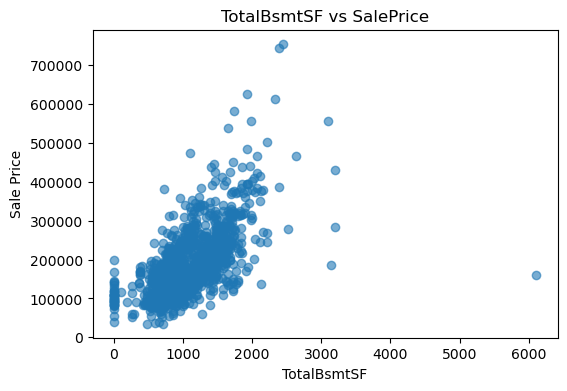

In [18]:
important_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

for feature in important_features:
    plt.figure(figsize=(6,4))

    plt.scatter(df[feature], df["SalePrice"], alpha=0.6)

    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("Sale Price")

    plt.show()

## Insights

- **OverallQual** shows a strong positive relationship with SalePrice. Houses with higher overall quality generally have higher selling prices.

- **GrLivArea** (Above Ground Living Area) has a clear positive linear relationship with SalePrice. Larger living areas tend to increase house prices.

- **GarageCars** also has a positive correlation. Houses with garages that can accommodate more cars are generally more expensive.

- **GarageArea** follows a similar trend. Larger garage space is associated with higher house prices.

- **TotalBsmtSF** shows a moderate to strong positive relationship. Homes with larger basement areas generally sell at higher prices.

- A few **outliers** can be observed in some features (especially GrLivArea), where unusually large houses do not follow the general pricing trend. These may require further investigation before model training.

- Overall, these features appear to be strong predictors of house prices and will be useful during the machine learning phase.

# Data Preprocessing

The exploratory data analysis is complete. The next step is data preprocessing, where the dataset will be prepared for machine learning.

The preprocessing process includes:

- Handling remaining missing values
- Encoding categorical variables
- Scaling numerical features (if required)
- Splitting the dataset into training and testing sets

In [19]:
df.isnull().sum().sort_values(ascending=False).head(20)


MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageCond       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageType       81
BsmtFinType2     38
BsmtExposure     38
BsmtFinType1     37
BsmtCond         37
BsmtQual         37
MasVnrArea        8
Electrical        1
BsmtFullBath      0
Functional        0
TotRmsAbvGrd      0
GrLivArea         0
HalfBath          0
dtype: int64

In [20]:
# Fill missing values in numerical columns using Median

numerical_columns = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())
# for column in numerical_columns:
#     df[column] = df[column].fillna(df[column].median())

In [21]:
# Fill missing values in categorical columns using "None"

categorical_columns = [
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[categorical_columns] = df[categorical_columns].fillna("None")
# for column in categorical_columns:
#     df[column] = df[column].fillna("None")

In [22]:
# Fill missing value using Mode

df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [23]:
df.isnull().sum().sort_values(ascending=False).head(20)

Id              0
HalfBath        0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
FullBath        0
HeatingQC       0
BsmtHalfBath    0
BsmtFullBath    0
GrLivArea       0
LowQualFinSF    0
2ndFlrSF        0
1stFlrSF        0
Electrical      0
GarageType      0
GarageYrBlt     0
dtype: int64

# Handling Remaining Missing Values

After removing columns with excessive missing values, the remaining missing values are handled using appropriate techniques.

Strategy used:

- **Median** for numerical features to reduce the impact of outliers.
- **"None"** for categorical features where missing values indicate the absence of that feature.
- **Mode** for categorical features with only a few missing values.

This ensures that the dataset is complete and ready for machine learning.

# Encoding Categorical Features

Machine learning algorithms cannot work directly with text (categorical) data.

Therefore, all categorical features are converted into numerical values using **One-Hot Encoding**.

This transformation allows the model to understand and learn patterns from categorical variables.

In [24]:
categorical_columns = df.select_dtypes(include="object").columns

print(f"Number of categorical columns: {len(categorical_columns)}")

categorical_columns

Number of categorical columns: 39


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

# One-Hot Encoding

Most machine learning algorithms cannot work directly with categorical (text) data.

Therefore, categorical features are converted into numerical features using **One-Hot Encoding**.

This process creates a new binary column for each category, allowing the model to use categorical information effectively.

In [25]:
# Apply One-Hot Encoding
df2 = df.copy()
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [26]:
df.shape


(1460, 248)

# Splitting Features and Target Variable

The dataset is now completely numerical and ready for machine learning.

The target variable (`SalePrice`) is separated from the input features.

- **X** contains all independent features.
- **y** contains the target variable (`SalePrice`).

In [27]:
# Features
X = df.drop("SalePrice", axis=1)

# Target
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 247)
(1460,)


# Train-Test Split

Before training the model, the dataset is divided into training and testing sets.

- The training set is used to train the model.
- The testing set is used to evaluate the model on unseen data.

This helps measure how well the model generalizes to new data.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1168, 247)
X_test  : (292, 247)
y_train : (1168,)
y_test  : (292,)


# Linear Regression Model

The first machine learning model used in this project is **Linear Regression**.

Linear Regression is a simple and widely used algorithm for predicting continuous numerical values.

This model serves as a baseline for comparing more advanced machine learning models later in the project.

In [29]:
from sklearn.linear_model import LinearRegression

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Predict House Prices

y_pred = model.predict(X_test)


In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 20667.18771447309
MSE : 2759384347.0070777
RMSE: 52529.84244224494
R² Score: 0.6402520215605011


# Model Evaluation

The Linear Regression model was evaluated using standard regression metrics.

Results:

- **MAE:** 20,667.19
- **MSE:** 2,759,384,347.01
- **RMSE:** 52,529.84
- **R² Score:** 0.6403

## Insights

- The model achieved an **R² Score of 0.64**, which means it can explain approximately **64% of the variation** in house prices.

- The **Mean Absolute Error (MAE)** is approximately **20,667**, indicating that on average the model's predictions differ from the actual house prices by about **$20,667**.

- The **RMSE** is higher than the MAE because larger prediction errors are penalized more heavily.

- Although the model provides a reasonable baseline, its performance can be improved by using more advanced machine learning algorithms such as **Random Forest Regressor** or **XGBoost Regressor**, which can capture complex non-linear relationships in the data.

# Train Random Forest Regressor

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [32]:
from sklearn.ensemble import RandomForestRegressor


In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [34]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

MAE : 17777.935273972602
MSE : 870960587.0776255
RMSE: 29512.0413912292
R² Score: 0.8864506458328288


# Random Forest Regressor Evaluation

The Random Forest Regressor significantly outperformed the Linear Regression model.

Results:

- **MAE:** 17,777.94
- **MSE:** 870,960,587.08
- **RMSE:** 29,512.04
- **R² Score:** 0.8865

## Insights

- The Random Forest model explains approximately **88.6%** of the variation in house prices.
- The average prediction error decreased from **20,667** (Linear Regression) to **17,778**.
- The RMSE also dropped significantly, indicating that large prediction errors were greatly reduced.
- Compared to Linear Regression, Random Forest captures complex and non-linear relationships between house features and prices, resulting in much higher prediction accuracy.

# Feature Importance Analysis

Random Forest provides an importance score for every feature used during training.

Higher importance indicates that the feature contributes more to predicting house prices.

This analysis helps identify the most influential features affecting house prices.

In [37]:
feature_importance = rf_model.feature_importances_

In [38]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
top10 = importance_df.head(10)


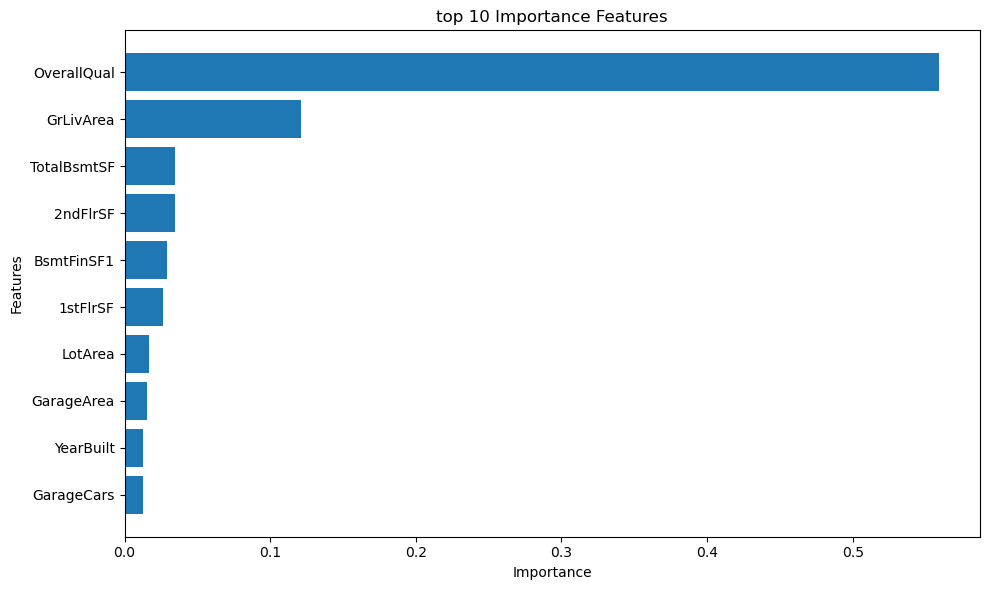

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.barh(
    top10['Feature'],
    top10['Importance']
)
plt.title('top 10 Importance Features')
plt.ylabel('Features')
plt.xlabel('Importance')


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Feature Importance Analysis

The Random Forest model was used to determine which features have the greatest influence on predicting house prices.

## Key Insights

- **OverallQual** is the most important feature, indicating that the overall quality of a house has the strongest impact on its selling price.
- **GrLivArea** is the second most influential feature, showing that larger living areas generally lead to higher house prices.
- **TotalBsmtSF**, **2ndFlrSF**, and **BsmtFinSF1** also contribute significantly to price prediction.
- Garage-related features such as **GarageArea** and **GarageCars** have a positive impact on house prices.
- The construction year (**YearBuilt**) also plays an important role, suggesting that newer houses tend to have higher market values.

Overall, the model indicates that **house quality, living space, basement size, and garage-related features are the primary factors influencing house prices**.

# Save the Trained Model

The trained Random Forest model was saved as a `.pkl` file using Joblib. This allows the model to be reused later without retraining, making deployment and future predictions faster and more efficient.

In [40]:
# import joblib

# joblib.dump(rf_model, "house_price_model.pkl")

# print("Model saved successfully!")

# XGBoost Regressor

After evaluating Linear Regression and Random Forest, an XGBoost Regressor was trained to further improve prediction performance.

XGBoost is an advanced gradient boosting algorithm that combines multiple decision trees sequentially to minimize prediction errors and achieve higher accuracy.

It is widely used in machine learning competitions and real-world regression problems because of its speed, robustness, and excellent predictive performance.


In [41]:
from xgboost import XGBRegressor

In [42]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [43]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [44]:
xgb_pred = xgb_model.predict(X_test)

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE:", xgb_rmse)
print("R² Score:", xgb_r2)

MAE : 17122.46875
MSE : 746520192.0
RMSE: 27322.521699140438
R² Score: 0.9026742577552795


In [46]:
# import joblib
# joblib.dump(xgb_model, "xgboost_house_price_model.pkl")

# Save Training Columns

The feature names used during model training were saved separately.

This ensures that new input data can be transformed into the exact same feature structure during prediction.

Saving the training columns prevents feature mismatch errors when making predictions on new house data.

In [ ]:
# import joblib

# # Save training column names
# joblib.dump(X_train.columns.tolist(), "models/model_columns.pkl")

# print("Training columns saved successfully!")

# Feature Importance Analysis

The trained XGBoost model was used to identify the most influential features affecting house prices.

Feature importance helps us understand which variables contribute the most to the prediction and allows us to simplify the model by selecting only the most relevant features for future deployment.

<Figure size 1200x1000 with 0 Axes>

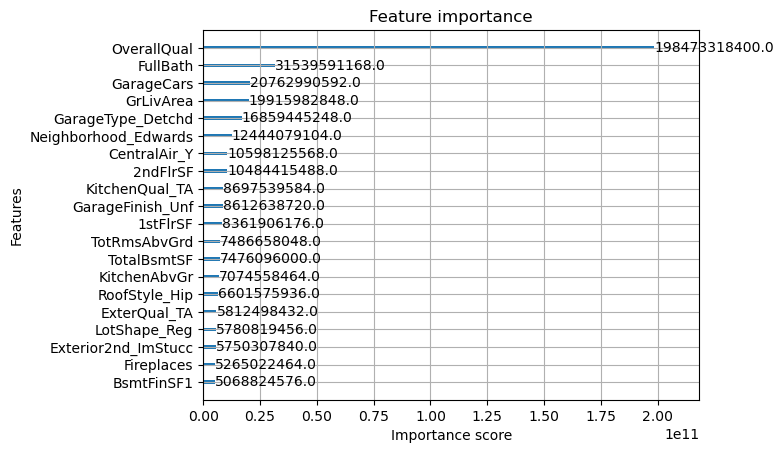

In [52]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plot_importance(
    xgb_model,
    max_num_features=20,
    importance_type="gain"
)

plt.show()

# Version 2 Model (Selected Features)

# Selected Features for Deployment

To make the final application simpler and more user-friendly, only the most important features were selected.

Reducing the number of input features makes the prediction form shorter while maintaining high prediction accuracy.

This version of the model is intended for deployment as a web application.

In [55]:
selected_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd",
    "LotArea",
    "Neighborhood",
    "KitchenQual",
    "GarageType",
    "GarageFinish",
    "CentralAir",
    "BsmtFinSF1",
    "Fireplaces",
    "LotShape",
    "RoofStyle"
]

# Create new dataframe
df_v2 = df2[selected_features + ["SalePrice"]]

df_v2.isnull().sum().sort_values(ascending=False)



OverallQual     0
Neighborhood    0
RoofStyle       0
LotShape        0
Fireplaces      0
BsmtFinSF1      0
CentralAir      0
GarageFinish    0
GarageType      0
KitchenQual     0
LotArea         0
GrLivArea       0
TotRmsAbvGrd    0
FullBath        0
YearBuilt       0
2ndFlrSF        0
1stFlrSF        0
TotalBsmtSF     0
GarageArea      0
GarageCars      0
SalePrice       0
dtype: int64

In [56]:
df_v2 = pd.get_dummies(df_v2, drop_first=True)

df_v2.shape

(1460, 59)

In [57]:
X = df_v2.drop("SalePrice", axis=1)
y = df_v2["SalePrice"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
from xgboost import XGBRegressor

xgb_model_v2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model_v2.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [60]:
y_pred = xgb_model_v2.predict(X_test)

In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 16935.6328125
MSE : 677089856.0
RMSE: 26020.950328533352
R² Score: 0.9117260575294495


In [62]:
import joblib

joblib.dump(xgb_model_v2, "models/xgboost_house_price_model_v2.pkl")

joblib.dump(
    X_train.columns.tolist(),
    "models/model_columns_v2.pkl"
)

['models/model_columns_v2.pkl']